In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 


In [15]:
data=pd.read_csv("preprocessed.csv")

In [16]:
data.head()

,Unnamed: 0,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,month,year,season,precipitation_log,weather_label
0,0,Ahmedabad,2000-01-01,29.9,15.3,29.1,12.8,0.0,0,14.5,30.2,60,1,2000,Winter,0.0,Clear sky
1,1,Bangalore,2000-01-01,24.6,13.7,23.5,13.2,0.0,3,14.5,34.9,91,1,2000,Winter,0.0,Overcast
2,2,Chennai,2000-01-01,27.1,22.6,28.1,23.2,0.0,2,22.4,38.9,51,1,2000,Winter,0.0,Partly cloudy
3,3,Delhi,2000-01-01,19.9,7.4,19.2,5.8,0.0,0,10.9,13.3,58,1,2000,Winter,0.0,Clear sky
4,4,Hyderabad,2000-01-01,26.8,16.5,25.5,17.3,0.0,2,13.9,29.9,108,1,2000,Winter,0.0,Partly cloudy


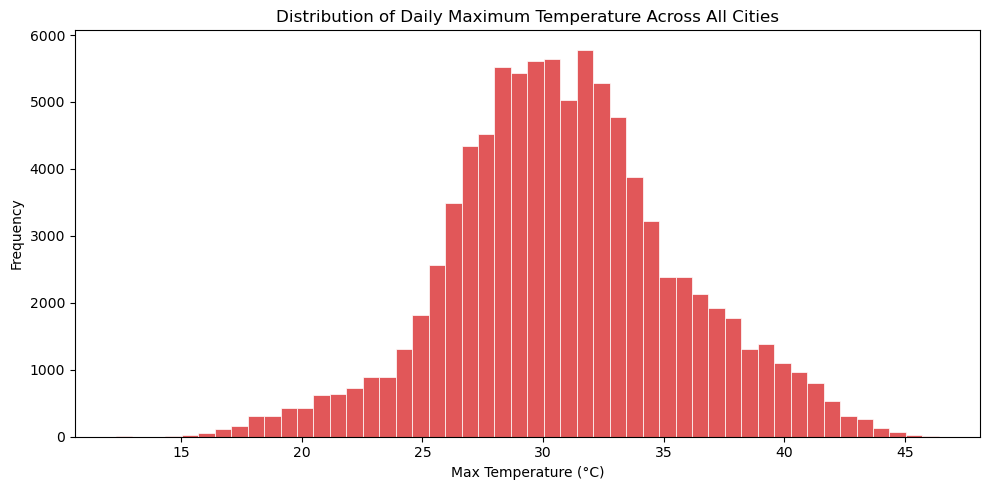

In [17]:
# Distribution of daily maximum temperature across all cities

plt.figure(figsize=(10, 5))
plt.hist(data['temperature_2m_max'], bins=50, color='#E15759', edgecolor='white', linewidth=0.5)
plt.title('Distribution of Daily Maximum Temperature Across All Cities')
plt.xlabel('Max Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/Distribution of daily maximum temperature across all cities.png', dpi=120)
plt.show()

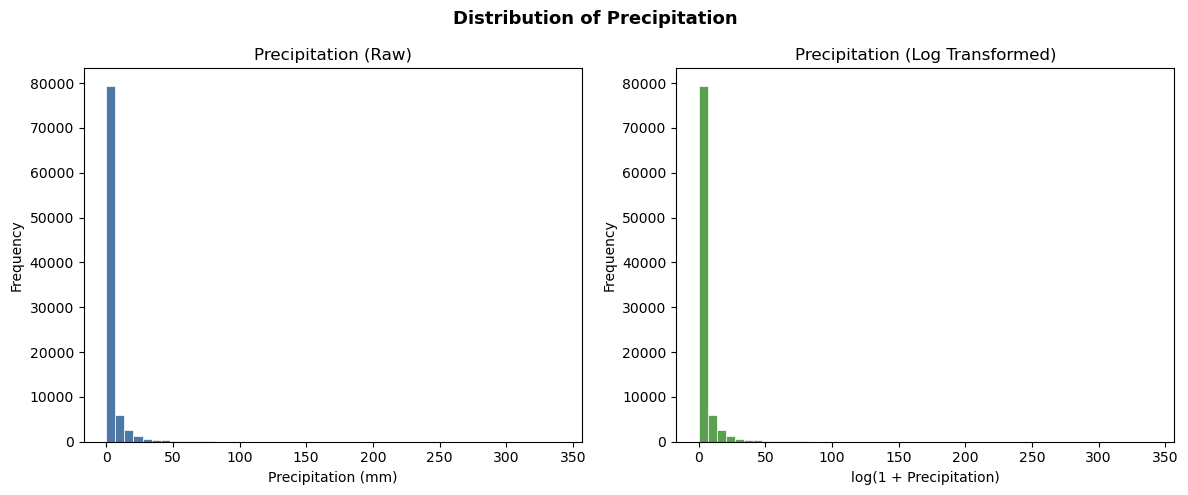

In [18]:
# Distribution of precipitation — raw vs log-transformed

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(data['precipitation_sum'], bins=50, color='#4E79A7', edgecolor='white', linewidth=0.5)
axes[0].set_title('Precipitation (Raw)')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Frequency')
axes[1].hist(data['precipitation_log'], bins=50, color='#59A14F', edgecolor='white', linewidth=0.5)
axes[1].set_title('Precipitation (Log Transformed)')
axes[1].set_xlabel('log(1 + Precipitation)')
axes[1].set_ylabel('Frequency')
plt.suptitle('Distribution of Precipitation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/distribution of precipitation raw and log transformed.png', dpi=120)
plt.show()

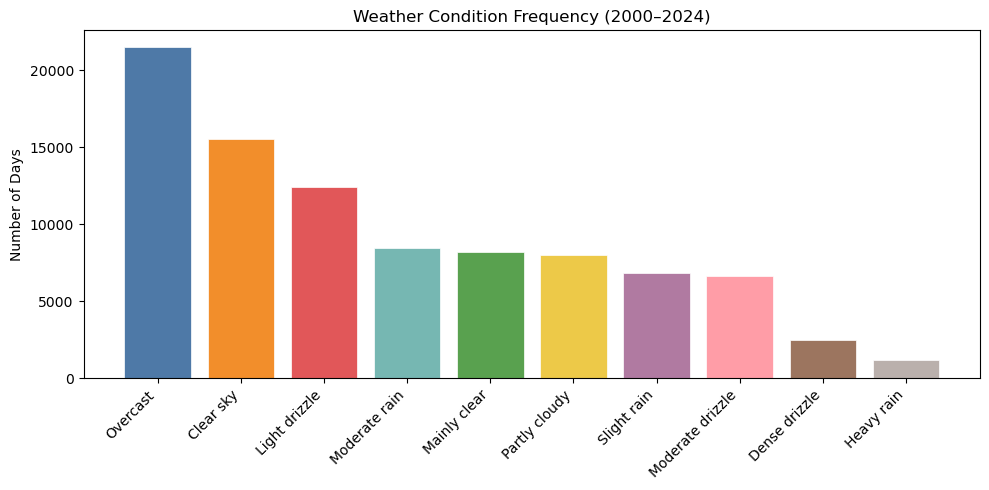

In [19]:
# Frequency of each weather condition

counts = data['weather_label'].value_counts()
bar_colors = ['#4E79A7','#F28E2B','#E15759','#76B7B2','#59A14F',
              '#EDC948','#B07AA1','#FF9DA7','#9C755F','#BAB0AC']
plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values, color=bar_colors[:len(counts)], edgecolor='white', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.title('Weather Condition Frequency (2000–2024)')
plt.ylabel('Number of Days')
plt.tight_layout()
plt.savefig('charts/Weather Condition Frequency (2000-2024).png', dpi=120)
plt.show()

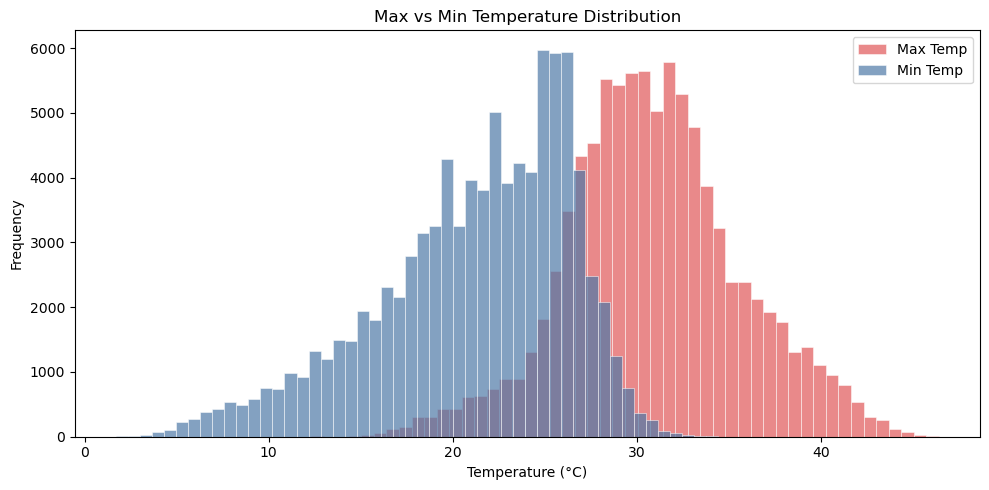

In [20]:
# Overlapping distribution of max and min temperature

plt.figure(figsize=(10, 5))
plt.hist(data['temperature_2m_max'], bins=50, alpha=0.7, label='Max Temp',
         color='#E15759', edgecolor='white', linewidth=0.5)
plt.hist(data['temperature_2m_min'], bins=50, alpha=0.7, label='Min Temp',
         color='#4E79A7', edgecolor='white', linewidth=0.5)
plt.legend()
plt.title('Max vs Min Temperature Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('charts/Max vs Min Temperature Distribution.png', dpi=120)
plt.show()

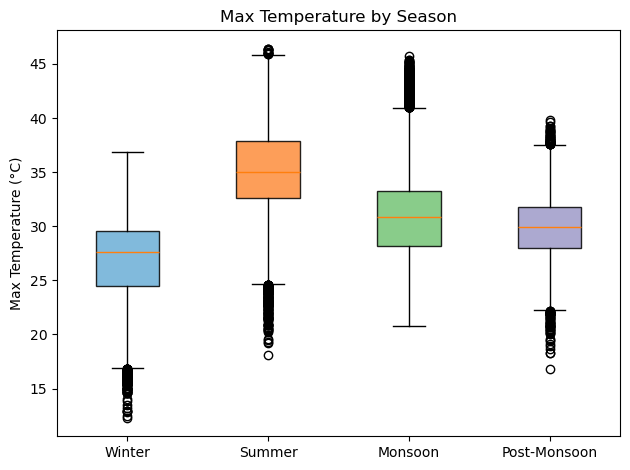

In [21]:
# Box plot of max temperature by season

season_order  = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_colors = ['#6BAED6', '#FD8D3C', '#74C476', '#9E9AC8']

data_by_seasons = [data[data['season'] == s]['temperature_2m_max'].values for s in season_order]
bp = plt.boxplot(data_by_seasons, tick_labels=season_order, patch_artist=True)
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
plt.title('Max Temperature by Season')
plt.ylabel('Max Temperature (°C)')
plt.tight_layout()
plt.savefig('charts/max temperature vs seasons box plot.png', dpi=120)
plt.show()

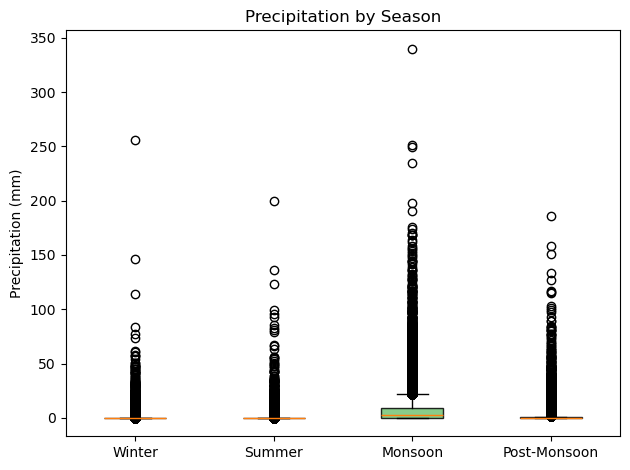

In [22]:
# Box plot of precipitation by season

season_order  = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_colors = ['#6BAED6', '#FD8D3C', '#74C476', '#9E9AC8']

data_by_seasons = [data[data['season'] == s]['precipitation_sum'].values for s in season_order]
bp = plt.boxplot(data_by_seasons, tick_labels=season_order, patch_artist=True)
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
plt.title('Precipitation by Season')
plt.ylabel('Precipitation (mm)')
plt.tight_layout()
plt.savefig('charts/precipitation vs seasons box plot.png', dpi=120)
plt.show()

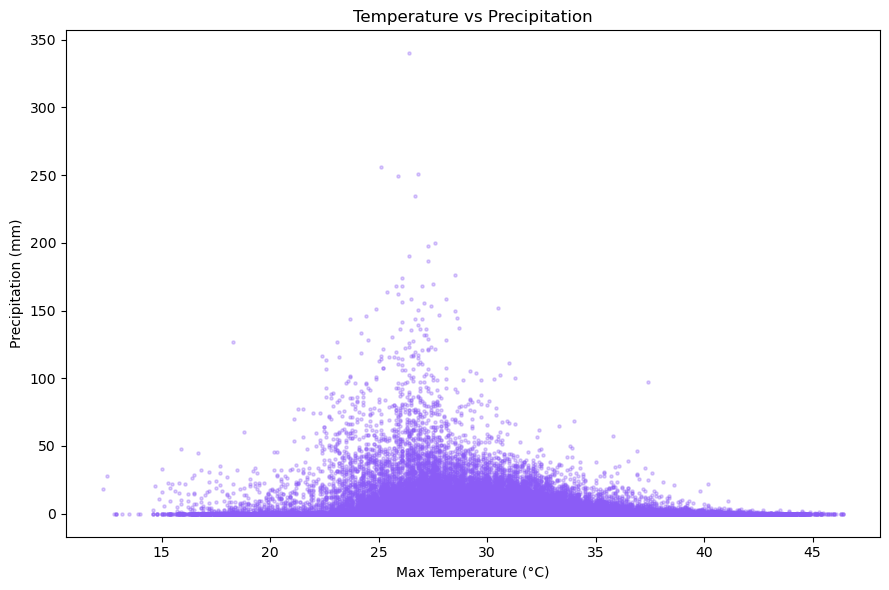

In [23]:
# Scatter plot: temperature vs precipitation

plt.figure(figsize=(9, 6))
plt.scatter(data['temperature_2m_max'], data['precipitation_sum'],
            alpha=0.3, s=5, color='#8B5CF6')
plt.xlabel('Max Temperature (°C)')
plt.ylabel('Precipitation (mm)')
plt.title('Temperature vs Precipitation')
plt.tight_layout()
plt.savefig('charts/temperature vs precipitation scatter plot.png', dpi=120)
plt.show()

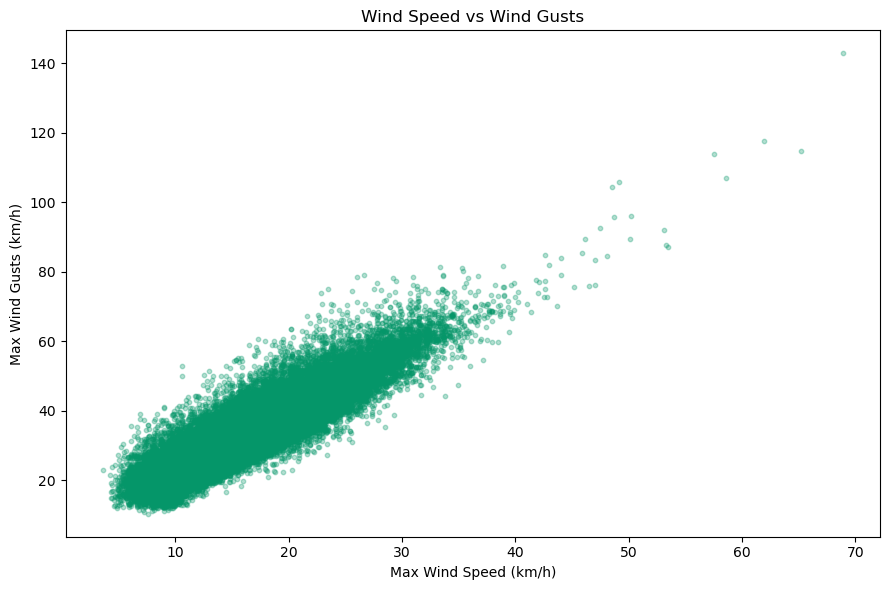

In [24]:
# Scatter plot: wind speed vs wind gusts

plt.figure(figsize=(9, 6))
plt.scatter(data['wind_speed_10m_max'], data['wind_gusts_10m_max'],
            alpha=0.3, s=10, color='#059669')
plt.xlabel('Max Wind Speed (km/h)')
plt.ylabel('Max Wind Gusts (km/h)')
plt.title('Wind Speed vs Wind Gusts')
plt.tight_layout()
plt.savefig('charts/wind speed vs wind gusts scatter plot.png', dpi=120)
plt.show()

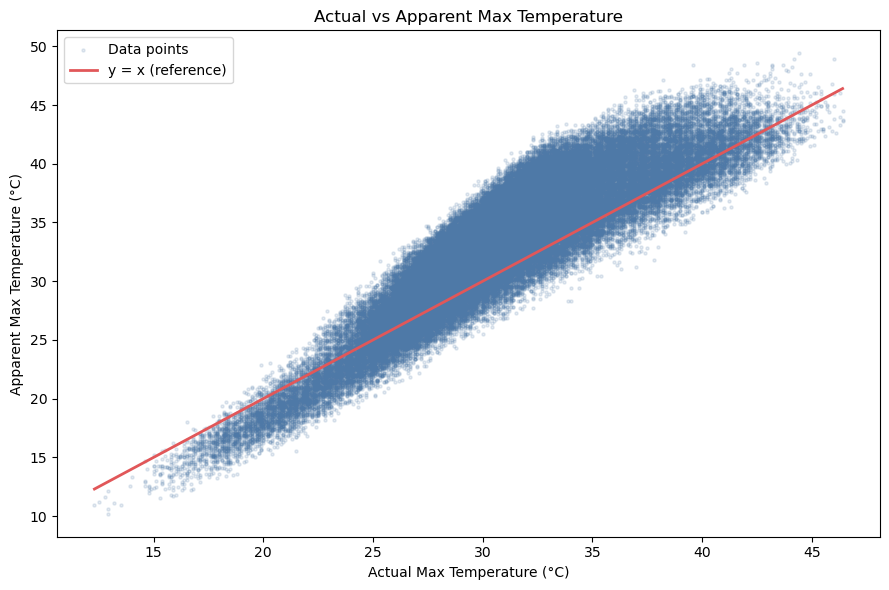

In [25]:
# Scatter plot: actual vs apparent max temperature

plt.figure(figsize=(9, 6))
plt.scatter(data['temperature_2m_max'], data['apparent_temperature_max'],
            alpha=0.15, s=5, color='#4E79A7', label='Data points')
plt.plot([data['temperature_2m_max'].min(), data['temperature_2m_max'].max()],
         [data['temperature_2m_max'].min(), data['temperature_2m_max'].max()],
         color='#E15759', linewidth=2, label='y = x (reference)')
plt.legend()
plt.xlabel('Actual Max Temperature (°C)')
plt.ylabel('Apparent Max Temperature (°C)')
plt.title('Actual vs Apparent Max Temperature')
plt.tight_layout()
plt.savefig('charts/temperature vs apparent temperature.png', dpi=120)
plt.show()

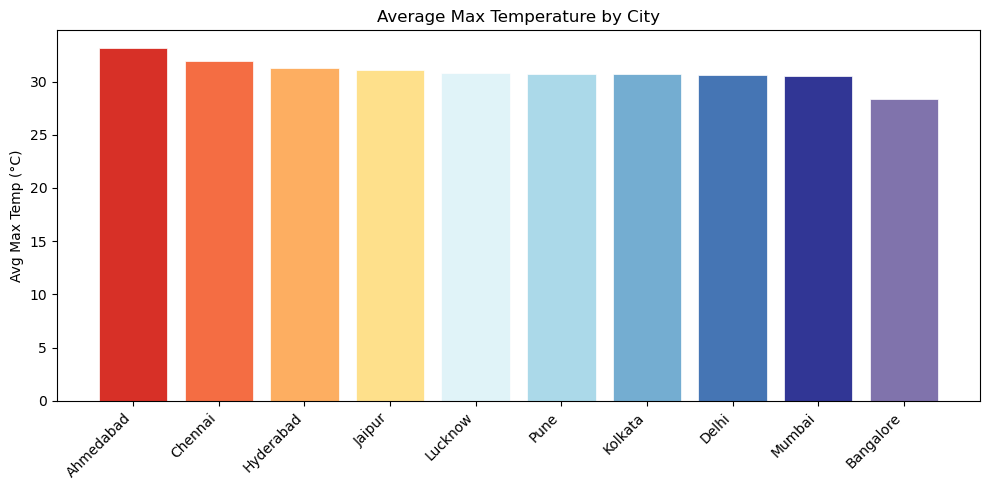

In [26]:
# Average max temperature per city

city_avg = data.groupby('city')['temperature_2m_max'].mean().sort_values(ascending=False)
city_colors = ['#D73027','#F46D43','#FDAE61','#FEE08B','#E0F3F8',
               '#ABD9E9','#74ADD1','#4575B4','#313695','#8073AC']
plt.figure(figsize=(10, 5))
plt.bar(city_avg.index, city_avg.values,
        color=city_colors[:len(city_avg)], edgecolor='white', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.title('Average Max Temperature by City')
plt.ylabel('Avg Max Temp (°C)')
plt.tight_layout()
plt.savefig('charts/average max temperature by city.png', dpi=120)
plt.show()

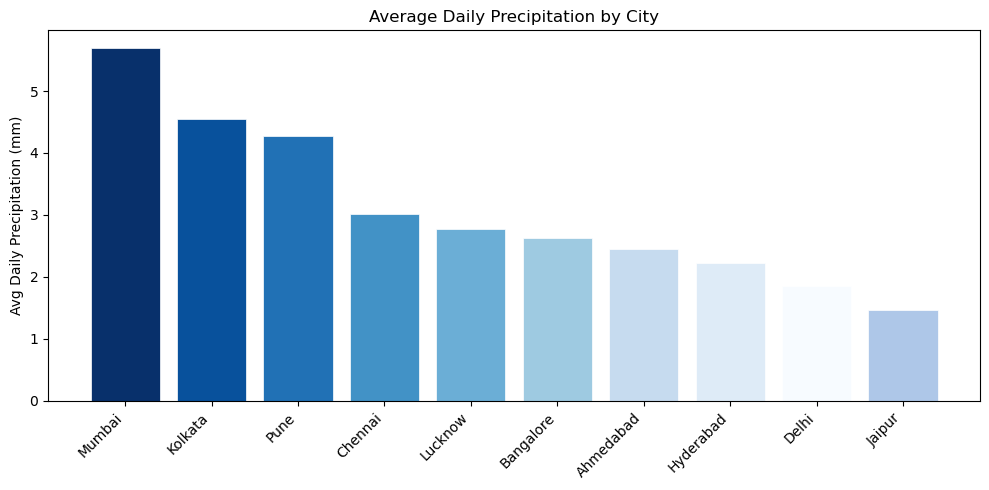

In [27]:
# Average daily precipitation per city

city_rain = data.groupby('city')['precipitation_sum'].mean().sort_values(ascending=False)
city_colors = ['#08306B','#08519C','#2171B5','#4292C6','#6BAED6',
               '#9ECAE1','#C6DBEF','#DEEBF7','#F7FBFF','#AEC7E8']
plt.figure(figsize=(10, 5))
plt.bar(city_rain.index, city_rain.values,
        color=city_colors[:len(city_rain)], edgecolor='white', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.title('Average Daily Precipitation by City')
plt.ylabel('Avg Daily Precipitation (mm)')
plt.tight_layout()
plt.savefig('charts/Average Daily Precipitation by City.png', dpi=120)
plt.show()

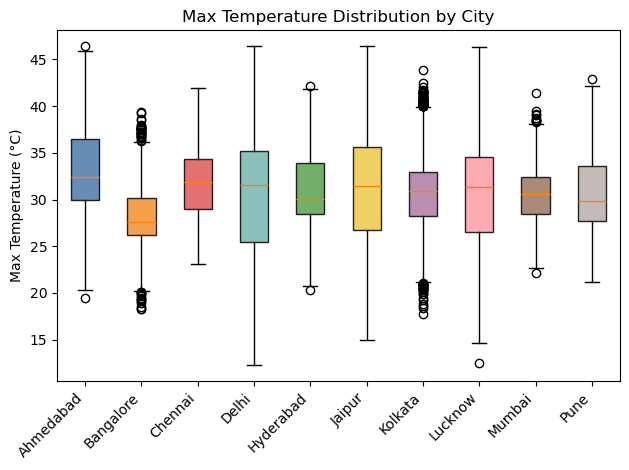

In [28]:
# Box plot of max temperature per city

city_order  = sorted(data['city'].unique())
city_colors = ['#4E79A7','#F28E2B','#E15759','#76B7B2','#59A14F',
               '#EDC948','#B07AA1','#FF9DA7','#9C755F','#BAB0AC']

data_by_city = [data[data['city'] == c]['temperature_2m_max'].values for c in city_order]
bp = plt.boxplot(data_by_city, tick_labels=city_order, patch_artist=True)
for patch, color in zip(bp['boxes'], city_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
plt.xticks(rotation=45, ha='right')
plt.title('Max Temperature Distribution by City')
plt.ylabel('Max Temperature (°C)')
plt.tight_layout()
plt.savefig('charts/Max Temperature Distribution by City.png', dpi=120)
plt.show()

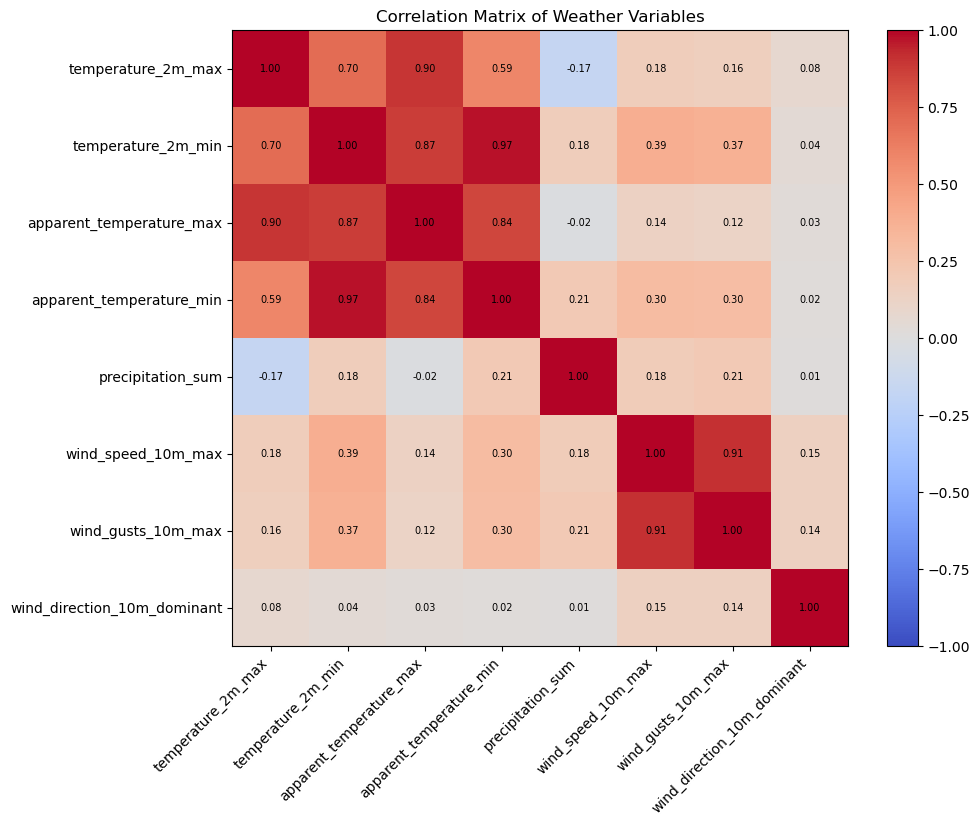

In [29]:
import numpy as np

num_cols = ['temperature_2m_max','temperature_2m_min','apparent_temperature_max',
            'apparent_temperature_min','precipitation_sum','wind_speed_10m_max',
            'wind_gusts_10m_max','wind_direction_10m_dominant']

corr = data[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)

# Annotate each cell
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

plt.title('Correlation Matrix of Weather Variables')
plt.savefig("charts/Correlation Matrix of Weather Variables.png")
plt.show()

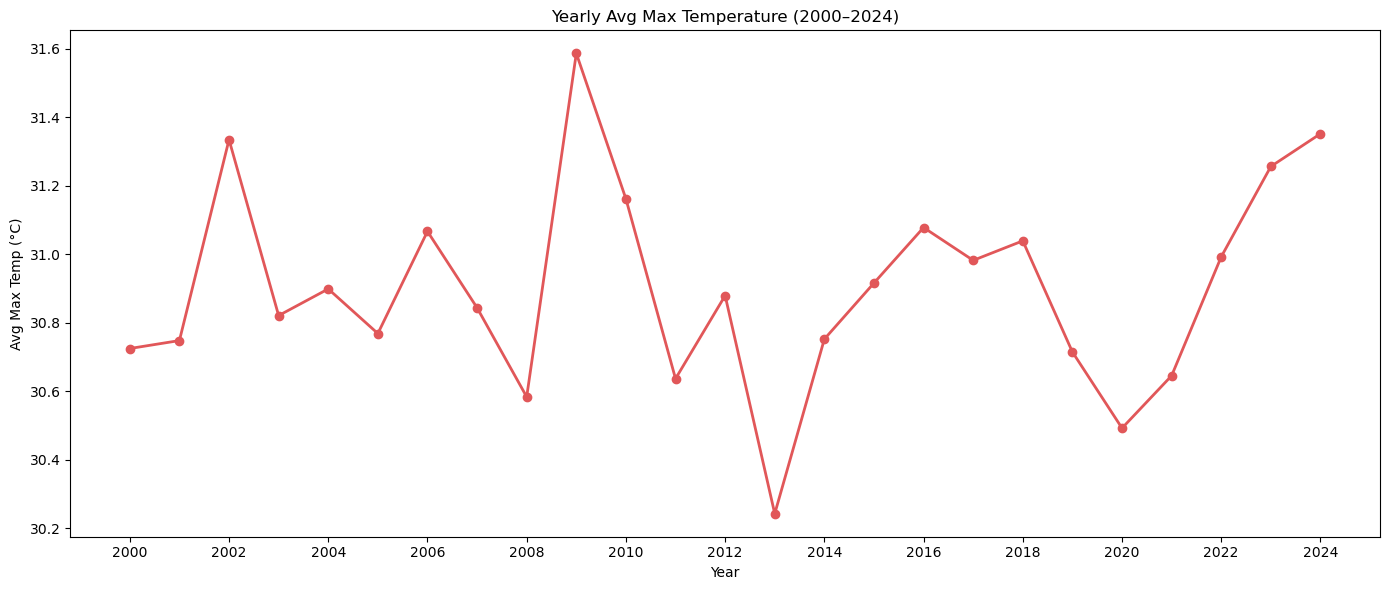

In [30]:
# Yearly average max temperature trend (2000-2024)

yearly = data.groupby('year')['temperature_2m_max'].mean()
plt.figure(figsize=(14, 6))
plt.plot(yearly.index, yearly.values, marker='o', color='#E15759', linewidth=2)
plt.xticks(range(2000, 2025, 2))
plt.title('Yearly Avg Max Temperature (2000–2024)')
plt.xlabel('Year')
plt.ylabel('Avg Max Temp (°C)')
plt.tight_layout()
plt.savefig('charts/Yearly Avg Max Temperature (2000-2024).png', dpi=120)
plt.show()

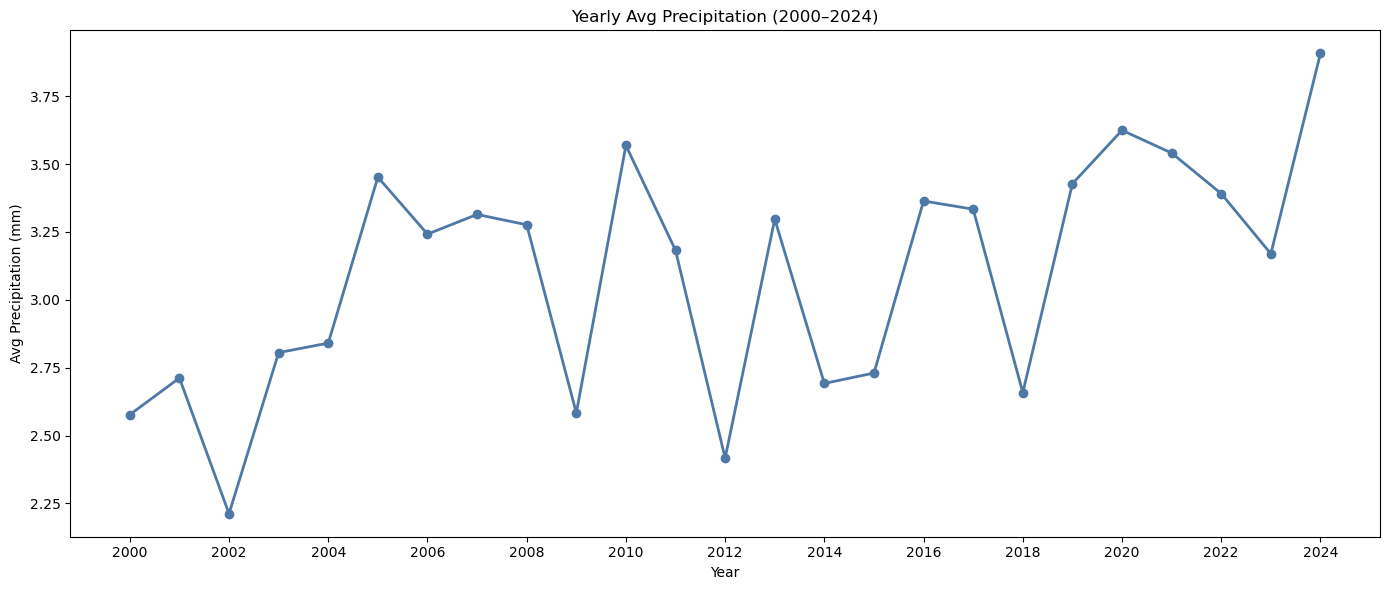

In [31]:
# Yearly average precipitation trend (2000-2024)

yearly = data.groupby('year')['precipitation_sum'].mean()
plt.figure(figsize=(14, 6))
plt.plot(yearly.index, yearly.values, marker='o', color='#4E79A7', linewidth=2)
plt.xticks(range(2000, 2025, 2))
plt.title('Yearly Avg Precipitation (2000–2024)')
plt.xlabel('Year')
plt.ylabel('Avg Precipitation (mm)')
plt.tight_layout()
plt.savefig('charts/Yearly Avg Precipitation (2000-2024).png', dpi=120)
plt.show()

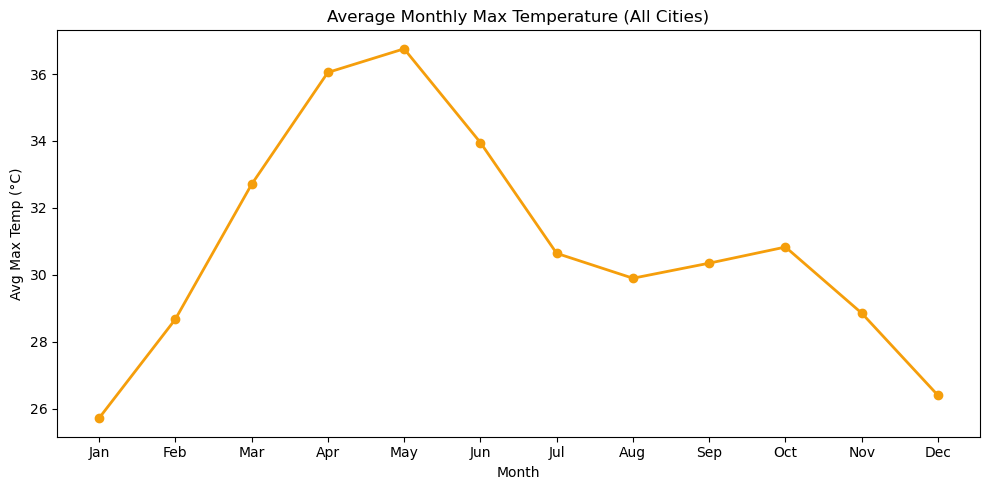

In [32]:
# Average monthly max temperature — seasonality

monthly = data.groupby('month')['temperature_2m_max'].mean()
months  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 5))
plt.plot(range(1, 13), monthly.values, marker='o', color='#F59E0B', linewidth=2)
plt.xticks(range(1, 13), months)
plt.title('Average Monthly Max Temperature (All Cities)')
plt.xlabel('Month')
plt.ylabel('Avg Max Temp (°C)')
plt.tight_layout()
plt.savefig('charts/average monthly max temperature.png', dpi=120)
plt.show()

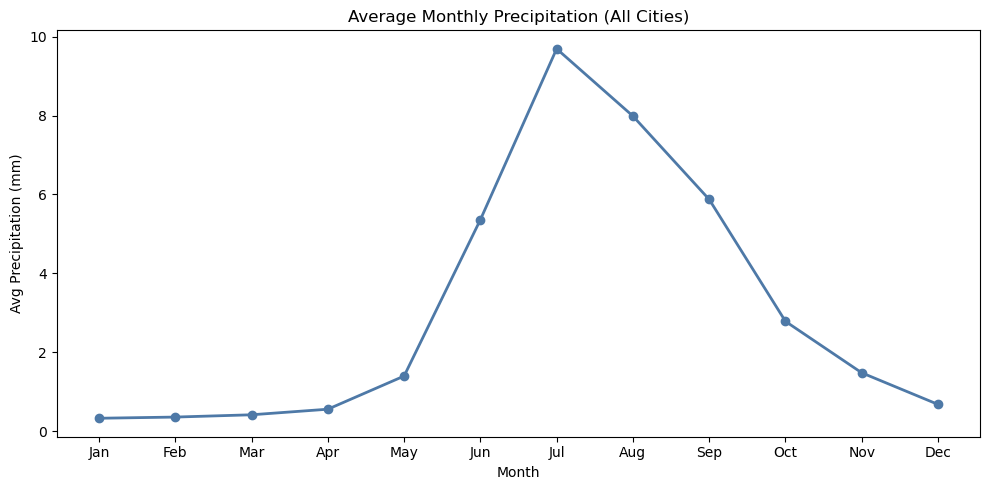

In [ ]:
# Average monthly precipitation — seasonality

monthly = data.groupby('month')['precipitation_sum'].mean()
months  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10, 5))
plt.plot(range(1, 13), monthly.values, marker='o', color='#4E79A7', linewidth=2)
plt.xticks(range(1, 13), months)
plt.title('Average Monthly Precipitation (All Cities)')
plt.xlabel('Month')
plt.ylabel('Avg Precipitation (mm)')
plt.tight_layout()
plt.savefig('charts/average monthly precipitation.png', dpi=120)
plt.show()